# Lab 3 — Requerimientos de la operación (hands-on)

**Modalidad:** hands-on · **Duración:** ~12 min
**Dataset:** `tickets.csv`

## Objetivo general
Caracterizar la **demanda operativa**: volumen por equipo, categoría y prioridad; cumplimiento de SLA y tasa de rollback de cambios.

## Buenas prácticas
- **NaN ≠ 0.** Si imputas, declara cómo (mediana, moda, drop).
- Outliers en tiempo de resolución suelen ser **incidentes** (lunes a las 9 a.m.).
- Un boxplot por equipo/prioridad te lo muestra en una sola imagen.

## Entregable
Un mini-reporte con 5 celdas: volumen, pivot, breach global, top-3 breach, rollback.

## 1. Carga + diagnóstico de NaN

**Qué buscamos:** saber si hay columnas con datos faltantes y dónde están.

**Por qué:** un NaN en `priority` cambia el cálculo de breach. Hay que recuperarlo antes.

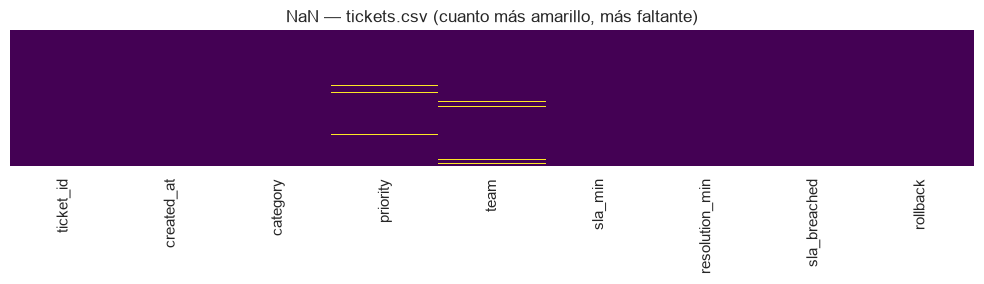

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

DATA = Path('..') / 'data'
tickets = pd.read_csv(DATA / 'tickets.csv', parse_dates=['created_at'])
tickets.shape
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(tickets.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('NaN — tickets.csv (cuanto más amarillo, más faltante)')
plt.tight_layout()
plt.savefig('../html/lab3_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

## 2. Volumen diario

**Qué vemos:** la serie temporal de tickets creados cada día.

**Qué buscar:** picos recurrentes (¿siempre los lunes a las 9?) y mesetas (¿estamos saturando al equipo?).

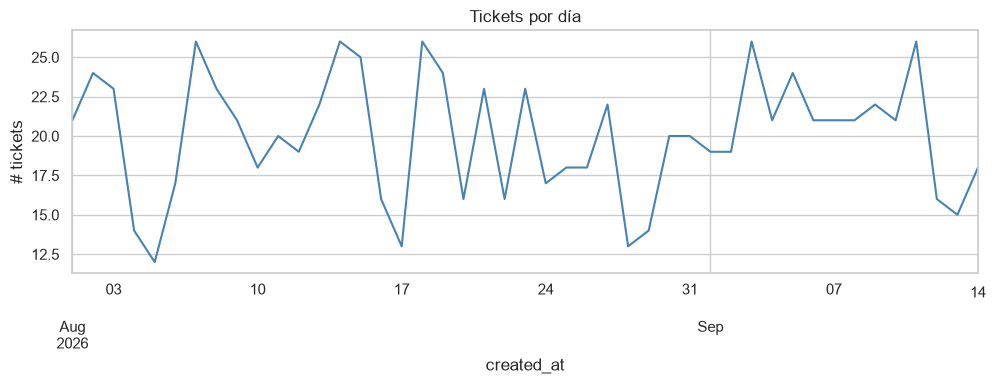

In [2]:
vol = tickets.set_index('created_at').resample('D').size()
fig, ax = plt.subplots(figsize=(10, 4))
vol.plot(ax=ax, color='steelblue')
ax.set_title('Tickets por día')
ax.set_ylabel('# tickets')
plt.tight_layout()
plt.savefig('../html/lab3_fig2_daily.png', dpi=110, bbox_inches='tight')
plt.show()

## 3. Heatmap team × categoría

**Qué buscamos:** dónde se concentra la carga operativa.

**Por qué:** con un solo vistazo sabemos a qué equipo pedirle soporte y en qué tipo de tickets.

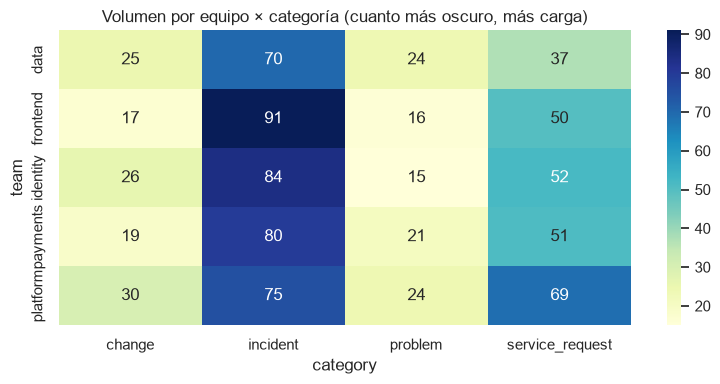

In [3]:
pivot = tickets.pivot_table(index='team', columns='category', values='ticket_id', aggfunc='count', fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Volumen por equipo × categoría (cuanto más oscuro, más carga)')
plt.tight_layout()
plt.savefig('../html/lab3_fig3_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Boxplot de tiempo de resolución por equipo (escala log)

**Qué vemos:** cada equipo como un boxplot distinto.

**Por qué la escala log:** porque la mezcla de minutos y días hace que la distribución sea muy asimétrica; sin log, los outliers aplastan todo.


**Qué buscamos:** saber qué servicios están sufriendo incidentes reales.

**Por qué importa Tukey (IQR × 1.5):**
- Media y p50 esconden los picos.
- La mediana es robusta, pero necesitamos un criterio operativo para etiquetar
  un valor como "anómalo" y actuar.

**Lectura del boxplot:**
- Caja = percentiles 25–75 (IQR).
- Rayita dentro = mediana.
- Bigotes = `Q3 + 1.5·IQR` (arriba) y `Q1 - 1.5·IQR` (abajo).
- Puntos fuera del bigote = outliers. Solo arriba = incidente unilateral.


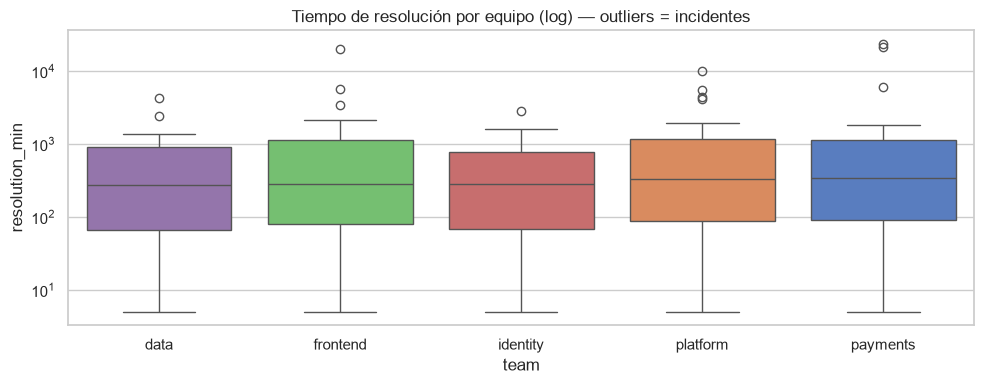

In [4]:
t = tickets[(tickets['resolution_min'] > 0) & (tickets['resolution_min'] < 100_000)].copy()
fig, ax = plt.subplots(figsize=(10, 4))
order = t.groupby('team')['resolution_min'].median().sort_values().index
sns.boxplot(data=t, x='team', y='resolution_min', order=order, hue='team', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Tiempo de resolución por equipo (log) — outliers = incidentes')
plt.tight_layout()
plt.savefig('../html/lab3_fig4_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Breach SLA — global y por equipo

**Qué entendemos por breach:** un ticket cuyo `resolution_min` supera el SLA definido en `sla_min`.

**Por qué importa:** breach alto en un equipo = cuello de capacidad o necesidad de automatizar.

Breach global: 38.22%


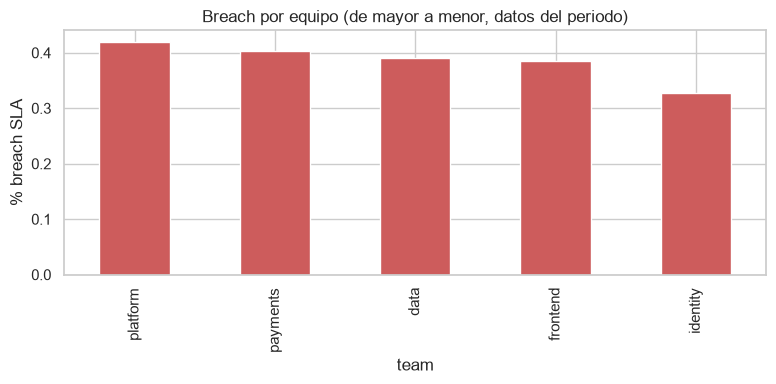

In [5]:
tickets['priority'] = tickets['priority'].fillna(tickets['priority'].mode().iloc[0])
print(f'Breach global: {tickets["sla_breached"].mean():.2%}')
fig, ax = plt.subplots(figsize=(8, 4))
tickets.groupby('team')['sla_breached'].mean().sort_values(ascending=False).plot(kind='bar', color='indianred', ax=ax)
ax.set_ylabel('% breach SLA')
ax.set_title('Breach por equipo (de mayor a menor, datos del periodo)')
plt.tight_layout()
plt.savefig('../html/lab3_fig5_breach.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Rollback en cambios

**Qué buscamos:** de los cambios (`category == 'change'`), cuántos terminaron en rollback.

**Por qué:** un rollback rate alto = cambios mal probados o sin revisión suficiente; candidato a postmortem.

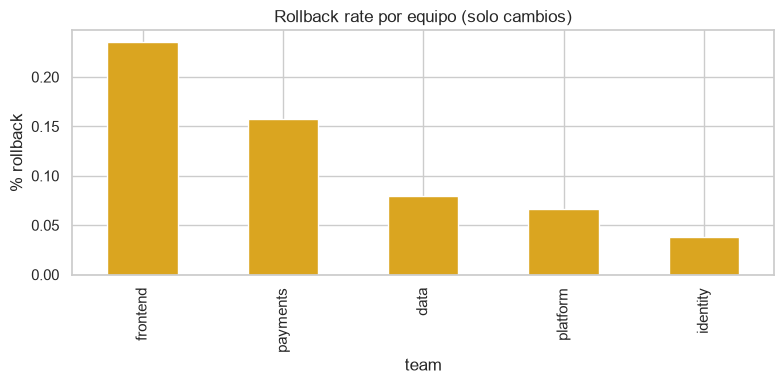

In [6]:
changes = tickets[tickets['category'] == 'change']
fig, ax = plt.subplots(figsize=(8, 4))
changes.groupby('team')['rollback'].mean().sort_values(ascending=False).plot(kind='bar', color='goldenrod', ax=ax)
ax.set_ylabel('% rollback')
ax.set_title('Rollback rate por equipo (solo cambios)')
plt.tight_layout()
plt.savefig('../html/lab3_fig6_rollback.png', dpi=110, bbox_inches='tight')
plt.show()

## Insights a compartir
- Equipo top en carga y equipo top en breach **¿son el mismo**?
- ¿Los outliers de resolución se concentran los **lunes 9 a.m.**?
- ¿Qué patrón de rollback merece un postmortem?